# Capstone Project - Social Media Engagement

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# 1. Load all 5 Excel files
df_post = pd.read_excel("post.xlsx")
df_engagement = pd.read_excel("engagement.xlsx")
df_sponsorship = pd.read_excel("sponsorship.xlsx")
df_creator = pd.read_excel("creator.xlsx")
df_audience = pd.read_excel("audience_demographics.xlsx")



In [4]:
df_post.head()

,content_id,creator_id,content_url,content_type,content_category,post_date,language,content_length,content_description,hashtags
0,content_20586,creator_586,http://www.hill-montgomery.com/,video,beauty,5/29/23 12:15 AM,Hindi,56,Professional radio usually something letter ha...,"or,according"
1,content_14129,creator_4129,https://anderson.com/,image,lifestyle,5/29/23 12:18 AM,Hindi,45,Short million quite cost drive century year pa...,"car,hair,save"
2,content_28653,creator_3653,https://www.ramos.com/,image,beauty,5/29/23 12:27 AM,English,122,Would financial receive decision tell nearly t...,NaN
3,content_10397,creator_397,http://www.smith-ferguson.com/,video,tech,5/29/23 12:34 AM,English,415,Go large human method movie college require co...,"world,girl"
4,content_35011,creator_11,https://kirk.com/,video,lifestyle,5/29/23 12:58 AM,Chinese,239,Increase everyone forward agency current know ...,"decide,their,value,kid"


In [5]:
df_creator

,creator_id,creator_name,platform,follower_count,audience_location
0,creator_586,nicole85,RedNote,216818,UK
1,creator_4129,irogers,Bilibili,325753,Germany
2,creator_3653,jessicaanderson,Bilibili,135224,Germany
3,creator_397,matthewyork,Bilibili,935412,Brazil
4,creator_11,robertmeyers,YouTube,117275,Russia
...,...,...,...,...,...
4995,creator_2675,nicholas28,YouTube,652511,Germany
4996,creator_4609,mjohnson,RedNote,251558,China
4997,creator_837,carl90,RedNote,185613,USA
4998,creator_200,sharon39,TikTok,441610,Brazil


In [6]:
df_audience

,audience_id,creator_id,audience_age_distribution,audience_gender_distribution,audience_location
0,902,creator_0,26-35,non-binary,Germany
1,1768,creator_0,26-35,male,USA
2,5611,creator_0,26-35,male,China
3,10021,creator_0,19-25,non-binary,Germany
4,19954,creator_0,19-25,female,Germany
...,...,...,...,...,...
49649,33834,creator_999,13-18,female,Germany
49650,33854,creator_999,26-35,male,India
49651,36881,creator_999,19-25,female,Germany
49652,39560,creator_999,36-50,female,China


In [7]:
df_engagement

,engagement_id,content_id,views,likes,shares,comments_count,comments_text
0,1,content_20586,9996,1469,284,197,Treat fast car bit hit blood. Recent hour situ...
1,2,content_14129,9929,1543,280,215,Mother land husband machine discussion.
2,3,content_28653,10005,1533,293,198,Watch case property try industry method hand. ...
3,4,content_10397,10098,1517,300,188,President seven attorney blue we. Morning thro...
4,5,content_35011,10126,1488,313,202,Glass ability author listen.
...,...,...,...,...,...,...,...
52209,52210,content_48364,9905,1477,270,196,Discover stock senior size no sister support. ...
52210,52211,content_45622,10109,1566,305,196,NaN
52211,52212,content_17266,10090,1507,295,221,Describe director national last both. Over sud...
52212,52213,content_17382,10170,1564,304,195,Daughter after dinner. Together child assume h...


In [8]:
df_sponsorship

,sponsorship_id,content_id,disclosure_type,sponsor_name,sponsor_category,disclosure_location
0,1,content_14129,explicit,"Zamora, Robinson and Sanchez",travel,hashtags
1,2,content_28653,implicit,"James, Davis and Kirby",food,video
2,3,content_47473,implicit,Wright-Thompson,cosmetics,caption
3,4,content_45817,explicit,Rivers Group,cosmetics,video
4,5,content_39603,explicit,Morris and Sons,fashion,caption
...,...,...,...,...,...,...
22309,22310,content_34561,explicit,Mcmahon Ltd,gaming,caption
22310,22311,content_45622,implicit,Castro-Bullock,gaming,caption
22311,22312,content_17266,implicit,Barrett-Miller,gaming,video
22312,22313,content_17382,implicit,"Ho, Randall and Butler",electronics,caption


## Data Merging 

In [3]:
# Step 1: Merge post data with engagement data on 'content_id'
# Using how='left' ensures we keep all posts even if they lack engagement data
df_merged = pd.merge(df_post, df_engagement, on='content_id', how='left')

# Step 2: Merge the result with sponsorship data on 'content_id'
df_merged = pd.merge(df_merged, df_sponsorship, on='content_id', how='left')

# Step 3: Merge the result with creator data on 'creator_id'
df_merged = pd.merge(df_merged, df_creator, on='creator_id', how='left')

# Step 4: Merge the result with audience demographics on 'creator_id'
df_merged = pd.merge(df_merged, df_audience, on='creator_id', how='left')

# Check the shape and the first few rows of the final merged DataFrame
print(f"Merged Data Shape: {df_merged.shape}")
display(df_merged.head())

# Step 5: Export the merged DataFrame to a single Excel file
output_path = 'merged_dataset.xlsx'
df_merged.to_excel(output_path, index=False)

print(f"\nSuccessfully saved the merged dataset to: {output_path}")

Merged Data Shape: (519645, 29)


,content_id,creator_id,content_url,content_type,content_category,post_date,language,content_length,content_description,hashtags,...,sponsor_category,disclosure_location,creator_name,platform,follower_count,audience_location_x,audience_id,audience_age_distribution,audience_gender_distribution,audience_location_y
0,content_20586,creator_586,http://www.hill-montgomery.com/,video,beauty,5/29/23 12:15 AM,Hindi,56,Professional radio usually something letter ha...,"or,according",...,NaN,NaN,nicole85,RedNote,216818,UK,1,19-25,unknown,UK
1,content_20586,creator_586,http://www.hill-montgomery.com/,video,beauty,5/29/23 12:15 AM,Hindi,56,Professional radio usually something letter ha...,"or,according",...,NaN,NaN,nicole85,RedNote,216818,UK,2586,36-50,male,Brazil
2,content_20586,creator_586,http://www.hill-montgomery.com/,video,beauty,5/29/23 12:15 AM,Hindi,56,Professional radio usually something letter ha...,"or,according",...,NaN,NaN,nicole85,RedNote,216818,UK,4612,13-18,female,USA
3,content_20586,creator_586,http://www.hill-montgomery.com/,video,beauty,5/29/23 12:15 AM,Hindi,56,Professional radio usually something letter ha...,"or,according",...,NaN,NaN,nicole85,RedNote,216818,UK,6650,19-25,female,Brazil
4,content_20586,creator_586,http://www.hill-montgomery.com/,video,beauty,5/29/23 12:15 AM,Hindi,56,Professional radio usually something letter ha...,"or,according",...,NaN,NaN,nicole85,RedNote,216818,UK,8654,13-18,male,Brazil



Successfully saved the merged dataset to: merged_dataset.xlsx


In [10]:
df_merged.tail()

,content_id,creator_id,content_url,content_type,content_category,post_date,language,content_length,content_description,hashtags,...,sponsor_category,disclosure_location,creator_name,platform,follower_count,audience_location_x,audience_id,audience_age_distribution,audience_gender_distribution,audience_location_y
519640,content_30057,creator_57,http://www.allen-ewing.info/,image,beauty,5/28/25 11:08 AM,Chinese,55,Visit several yourself area attention hard tal...,NaN,...,electronics,video,elliottkatrina,YouTube,145089,Japan,38401,26-35,male,India
519641,content_30057,creator_57,http://www.allen-ewing.info/,image,beauty,5/28/25 11:08 AM,Chinese,55,Visit several yourself area attention hard tal...,NaN,...,electronics,video,elliottkatrina,YouTube,145089,Japan,45649,13-18,female,Russia
519642,content_30057,creator_57,http://www.allen-ewing.info/,image,beauty,5/28/25 11:08 AM,Chinese,55,Visit several yourself area attention hard tal...,NaN,...,electronics,video,elliottkatrina,YouTube,145089,Japan,45781,26-35,female,USA
519643,content_30057,creator_57,http://www.allen-ewing.info/,image,beauty,5/28/25 11:08 AM,Chinese,55,Visit several yourself area attention hard tal...,NaN,...,electronics,video,elliottkatrina,YouTube,145089,Japan,46304,13-18,male,China
519644,content_30057,creator_57,http://www.allen-ewing.info/,image,beauty,5/28/25 11:08 AM,Chinese,55,Visit several yourself area attention hard tal...,NaN,...,electronics,video,elliottkatrina,YouTube,145089,Japan,49654,26-35,male,USA


In [11]:
df_merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 519645 entries, 0 to 519644
Data columns (total 29 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   content_id                    519645 non-null  str    
 1   creator_id                    519645 non-null  str    
 2   content_url                   519645 non-null  str    
 3   content_type                  519645 non-null  str    
 4   content_category              519645 non-null  str    
 5   post_date                     519645 non-null  object 
 6   language                      519645 non-null  str    
 7   content_length                519645 non-null  int64  
 8   content_description           519645 non-null  str    
 9   hashtags                      432686 non-null  object 
 10  engagement_id                 519645 non-null  int64  
 11  views                         519645 non-null  int64  
 12  likes                         519645 non-null  int64  


## Missing Value Treatment


In [4]:
missing_values = df_merged.isnull().sum()
print("Missing values per Column")
print(missing_values)

Missing values per Column
content_id                           0
creator_id                           0
content_url                          0
content_type                         0
content_category                     0
post_date                            0
language                             0
content_length                       0
content_description                  0
hashtags                         86959
engagement_id                        0
views                                0
likes                                0
shares                               0
comments_count                       0
comments_text                    86417
sponsorship_id                  297616
disclosure_type                 297616
sponsor_name                    297616
sponsor_category                297616
disclosure_location             297616
creator_name                         0
platform                             0
follower_count                       0
audience_location_x                  0

In [4]:
# 1. Handle Sponsorship columns (Fill with placeholders since missing means "Organic Post")
sponsor_text_cols = ['disclosure_type', 'sponsor_name', 'sponsor_category', 'disclosure_location']
df_merged[sponsor_text_cols] = df_merged[sponsor_text_cols].fillna('Not Sponsored')

# For the sponsorship ID, we can fill missing values with 0
df_merged['sponsorship_id'] = df_merged['sponsorship_id'].fillna(0).astype(int)

# 2. Handle Content text columns
df_merged['hashtags'] = df_merged['hashtags'].fillna('No Hashtags')
df_merged['comments_text'] = df_merged['comments_text'].fillna('No Text')

# 3. Verify that there are no more missing values
print("Remaining missing values per column:")
print(df_merged.isnull().sum())

#  Resave the fully cleaned dataset to Excel
df_merged.to_excel('merged_dataset_cleaned.xlsx', index=False)
print("\nFully cleaned dataset saved successfully!")

Remaining missing values per column:
content_id                      0
creator_id                      0
content_url                     0
content_type                    0
content_category                0
post_date                       0
language                        0
content_length                  0
content_description             0
hashtags                        0
engagement_id                   0
views                           0
likes                           0
shares                          0
comments_count                  0
comments_text                   0
sponsorship_id                  0
disclosure_type                 0
sponsor_name                    0
sponsor_category                0
disclosure_location             0
creator_name                    0
platform                        0
follower_count                  0
audience_location_x             0
audience_id                     0
audience_age_distribution       0
audience_gender_distribution    0
audience_lo

In [14]:
duplicate_count = df_merged.duplicated().sum()
print("Total Duplicate Rows ")
print(f"Total duplicates found: {duplicate_count}")

Total Duplicate Rows 
Total duplicates found: 0


## Outliers Treatment

In [5]:
# Define the numerical columns prone to outliers
numerical_cols = ['views', 'likes', 'shares', 'comments_count', 'content_length']

print(" Outlier Detection Count ")
for col in numerical_cols:
    Q1 = df_merged[col].quantile(0.25)
    Q3 = df_merged[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers_count = df_merged[(df_merged[col] < lower_bound) | (df_merged[col] > upper_bound)].shape[0]
    print(f"{col}: {outliers_count} outliers found")

 Outlier Detection Count 
views: 3478 outliers found
likes: 4186 outliers found
shares: 2573 outliers found
comments_count: 2012 outliers found
content_length: 0 outliers found


In [6]:
# Cap values outside the 1.5 * IQR boundaries
for col in numerical_cols:
    Q1 = df_merged[col].quantile(0.25)
    Q3 = df_merged[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # np.clip automatically forces values below lower_bound up to lower_bound, 
    # and values above upper_bound down to upper_bound
    df_merged[col] = np.clip(df_merged[col], lower_bound, upper_bound)

print("Outlier treatment complete! Extreme tails have been smoothly capped.")

#  Save your fully pristine dataset
df_merged.to_excel('merged_dataset_final.xlsx', index=False)
print("Saved final outlier-treated dataset to Excel!")

Outlier treatment complete! Extreme tails have been smoothly capped.
Saved final outlier-treated dataset to Excel!


In [17]:
df_merged.describe()

,content_length,engagement_id,views,likes,shares,comments_count,sponsorship_id,follower_count,audience_id
count,519645.000000,519645.000000,519645.000000,519645.000000,519645.000000,519645.000000,519645.000000,519645.000000,519645.000000
mean,229.487081,26102.248652,10100.288339,1510.249010,300.010584,200.018093,4765.609545,498278.033609,24828.434710
std,167.097999,15076.390162,99.468009,38.641886,17.214234,14.037407,6941.737168,290330.556256,14336.563995
min,10.000000,1.000000,9828.000000,1406.000000,252.000000,160.000000,0.000000,1069.000000,1.000000
25%,95.000000,13035.000000,10032.000000,1484.000000,288.000000,190.000000,0.000000,247179.000000,12408.000000
50%,174.000000,26102.000000,10100.000000,1510.000000,300.000000,200.000000,0.000000,498109.000000,24828.000000
75%,360.000000,39162.000000,10168.000000,1536.000000,312.000000,210.000000,9248.000000,753121.000000,37246.000000
max,599.000000,52214.000000,10372.000000,1614.000000,348.000000,240.000000,22314.000000,999986.000000,49654.000000


In [18]:
df_merged[['views', 'likes', 'shares', 'comments_count', 'follower_count']].describe()

,views,likes,shares,comments_count,follower_count
count,519645.000000,519645.000000,519645.000000,519645.000000,519645.000000
mean,10100.288339,1510.249010,300.010584,200.018093,498278.033609
std,99.468009,38.641886,17.214234,14.037407,290330.556256
min,9828.000000,1406.000000,252.000000,160.000000,1069.000000
25%,10032.000000,1484.000000,288.000000,190.000000,247179.000000
50%,10100.000000,1510.000000,300.000000,200.000000,498109.000000
75%,10168.000000,1536.000000,312.000000,210.000000,753121.000000
max,10372.000000,1614.000000,348.000000,240.000000,999986.000000


## EDA

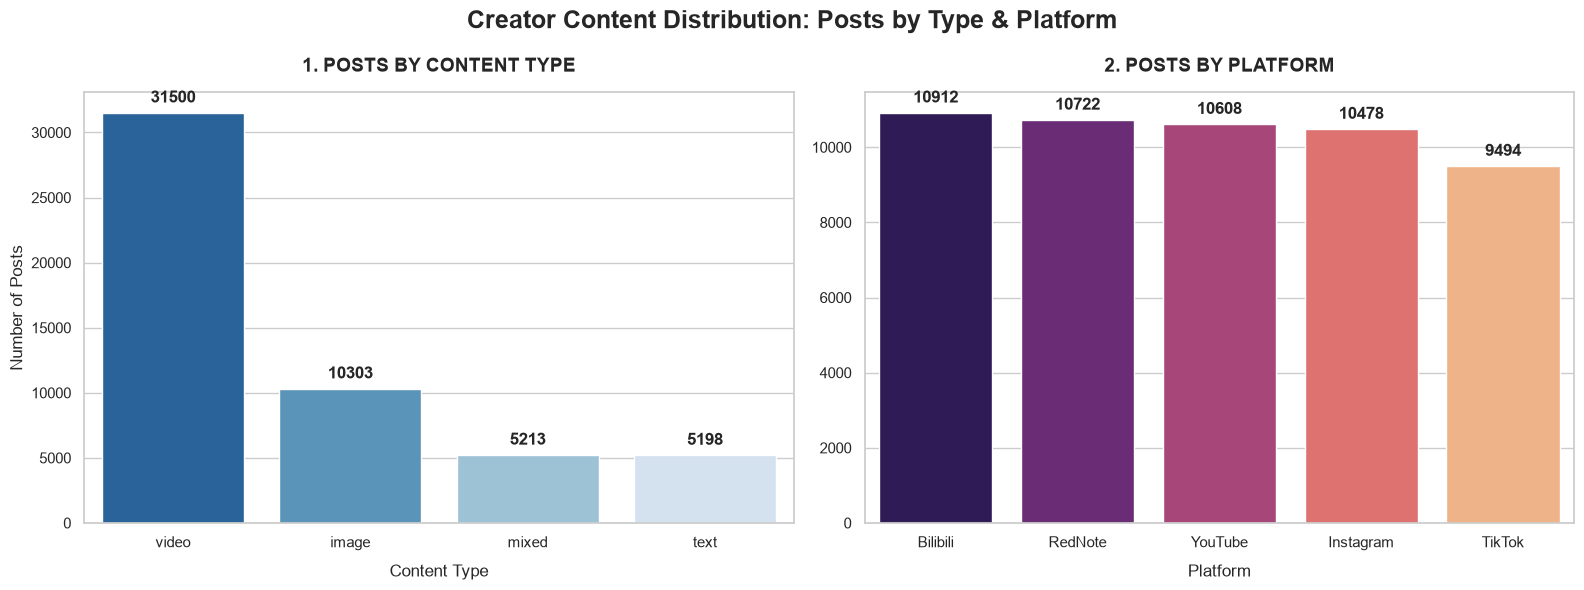

In [7]:
# Step 1: Isolate unique posts so we don't over-count due to the audience merge
df_unique = df_merged.drop_duplicates(subset=['content_id']).copy()

# Step 2: Calculate the exact counts for Content Type and Platform
content_counts = df_unique['content_type'].value_counts().reset_index()
content_counts.columns = ['content_type', 'post_count']

platform_counts = df_unique['platform'].value_counts().reset_index()
platform_counts.columns = ['platform', 'post_count']

# Step 3: Set up the visualization grid
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Creator Content Distribution: Posts by Type & Platform', fontsize=18, fontweight='bold')

# --- Plot 1: Posts by Content Type ---
sns.barplot(
    data=content_counts, 
    x='content_type', 
    y='post_count', 
    ax=axes[0], 
    palette='Blues_r',
    hue='content_type',
    legend=False
)
axes[0].set_title('1. POSTS BY CONTENT TYPE', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Content Type', fontsize=12, labelpad=10)
axes[0].set_ylabel('Number of Posts', fontsize=12)

# Add numeric data labels on top of the bars
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d', fontsize=12, fontweight='bold', padding=5)

# --- Plot 2: Posts by Platform ---
sns.barplot(
    data=platform_counts, 
    x='platform', 
    y='post_count', 
    ax=axes[1], 
    palette='magma',
    hue='platform',
    legend=False
)
axes[1].set_title('2. POSTS BY PLATFORM', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Platform', fontsize=12, labelpad=10)
axes[1].set_ylabel('', fontsize=12)

# Add numeric data labels on top of the bars
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%d', fontsize=12, fontweight='bold', padding=5)

# Step 4: Final polish and render
plt.tight_layout()
plt.show()

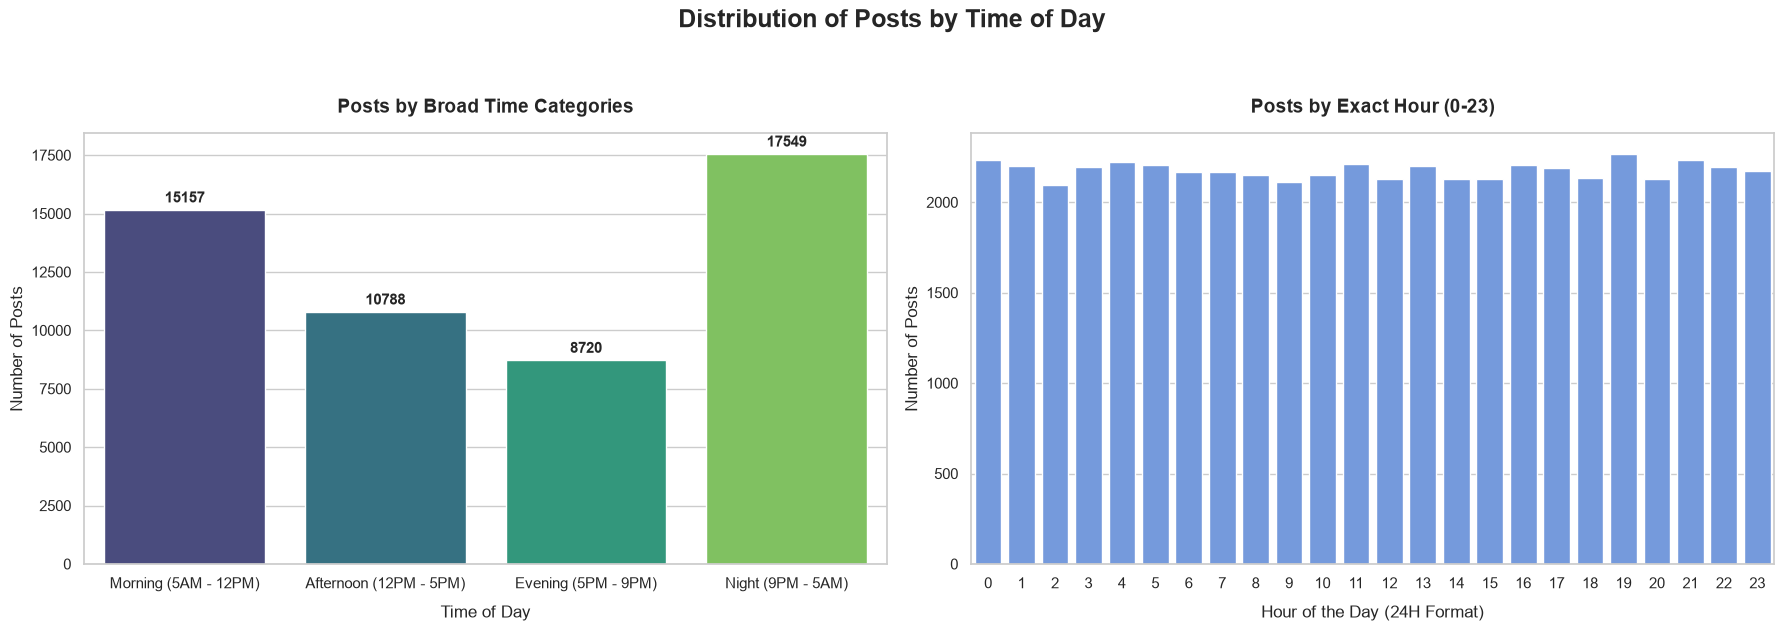

In [8]:
# Step 1: Isolate unique posts so we don't over-count
df_unique = df_merged.drop_duplicates(subset=['content_id']).copy()

# Step 2: Convert the post_date column to actual datetime objects
df_unique['post_date'] = pd.to_datetime(df_unique['post_date'])

# Extract the exact hour (0 to 23)
df_unique['post_hour'] = df_unique['post_date'].dt.hour

# Create a function to group hours into broad time blocks
def categorize_time(hour):
    if 5 <= hour < 12:
        return 'Morning (5AM - 12PM)'
    elif 12 <= hour < 17:
        return 'Afternoon (12PM - 5PM)'
    elif 17 <= hour < 21:
        return 'Evening (5PM - 9PM)'
    else:
        return 'Night (9PM - 5AM)'

# Apply the category function
df_unique['time_of_day'] = df_unique['post_hour'].apply(categorize_time)

# --- Aggregate the Data ---
# 1. By Time Block
time_order = ['Morning (5AM - 12PM)', 'Afternoon (12PM - 5PM)', 'Evening (5PM - 9PM)', 'Night (9PM - 5AM)']
time_counts = df_unique['time_of_day'].value_counts().reindex(time_order).reset_index()
time_counts.columns = ['time_of_day', 'post_count']

# 2. By Exact Hour
hour_counts = df_unique['post_hour'].value_counts().reset_index()
hour_counts.columns = ['post_hour', 'post_count']
hour_counts = hour_counts.sort_values('post_hour')

# Step 3: Set up the visualization grid
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Distribution of Posts by Time of Day', fontsize=18, fontweight='bold', y=1.05)

# --- Plot 1: Posts by Broad Time Block ---
sns.barplot(
    data=time_counts, 
    x='time_of_day', 
    y='post_count', 
    ax=axes[0], 
    palette='viridis', 
    hue='time_of_day', 
    legend=False
)
axes[0].set_title('Posts by Broad Time Categories', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Time of Day', fontsize=12, labelpad=10)
axes[0].set_ylabel('Number of Posts', fontsize=12)

# Add exact numbers on top of the bars
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d', fontsize=11, fontweight='bold', padding=3)

# --- Plot 2: Posts by Exact Hour ---
sns.barplot(
    data=hour_counts, 
    x='post_hour', 
    y='post_count', 
    ax=axes[1], 
    color='cornflowerblue'
)
axes[1].set_title('Posts by Exact Hour (0-23)', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Hour of the Day (24H Format)', fontsize=12, labelpad=10)
axes[1].set_ylabel('Number of Posts', fontsize=12)

# Step 4: Final polish and render
plt.tight_layout()
plt.show()

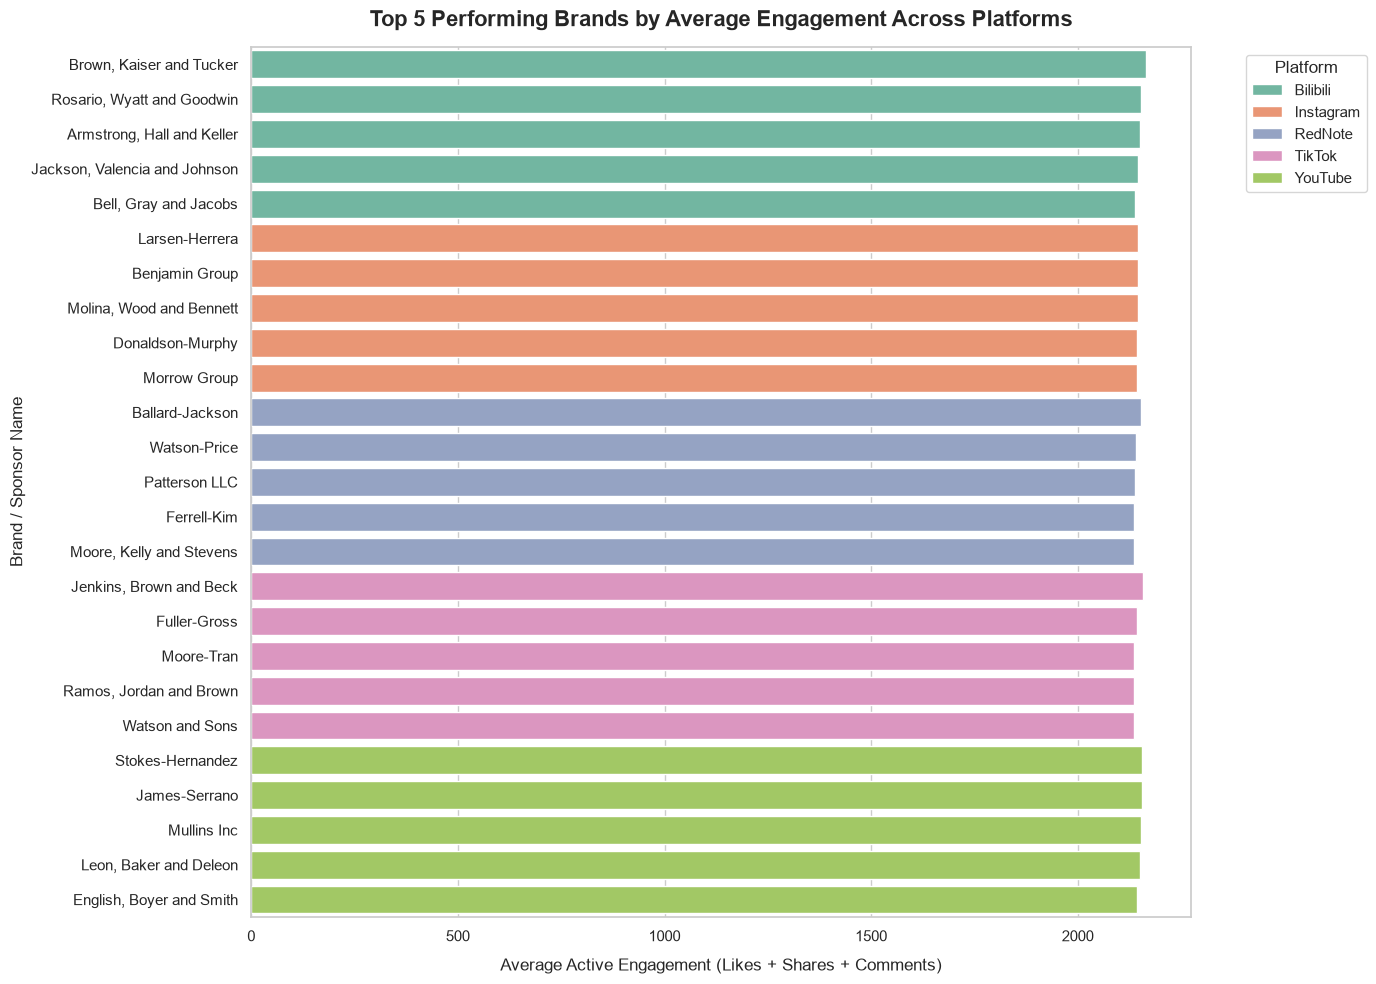


--- Top Brands by Platform (Tabular Data) ---


,platform,sponsor_name,total_engagement
409,Bilibili,"Brown, Kaiser and Tucker",2166.0
3280,Bilibili,"Rosario, Wyatt and Goodwin",2154.0
120,Bilibili,"Armstrong, Hall and Keller",2150.0
1789,Bilibili,"Jackson, Valencia and Johnson",2146.0
279,Bilibili,"Bell, Gray and Jacobs",2139.0
6260,Instagram,Larsen-Herrera,2146.0
4502,Instagram,Benjamin Group,2145.0
6690,Instagram,"Molina, Wood and Bennett",2145.0
5141,Instagram,Donaldson-Murphy,2143.0
6762,Instagram,Morrow Group,2143.0


In [9]:
# 1. Filter for actual sponsored posts only (excluding 'Not Sponsored')
df_sponsored = df_merged[df_merged['sponsor_name'] != 'Not Sponsored'].copy()

# 2. Create a total engagement metric (excluding views to focus on active interactions)
df_sponsored['total_engagement'] = df_sponsored['likes'] + df_sponsored['shares'] + df_sponsored['comments_count']

# 3. Group by Platform and Sponsor Name to get the average engagement per brand
brand_performance = df_sponsored.groupby(['platform', 'sponsor_name'])['total_engagement'].mean().reset_index()

# 4. Extract the Top 5 performing brands for each platform
top_brands_by_platform = (brand_performance
                          .sort_values(['platform', 'total_engagement'], ascending=[True, False])
                          .groupby('platform')
                          .head(5))

# --- 5. Visualizing the Data ---

sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 10))

# Plot a bar chart
ax = sns.barplot(
    data=top_brands_by_platform,
    x='total_engagement',
    y='sponsor_name',
    hue='platform',
    dodge=False, # Keeps bars aligned nicely
    palette='Set2'
)

plt.title('Top 5 Performing Brands by Average Engagement Across Platforms', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Average Active Engagement (Likes + Shares + Comments)', fontsize=12, labelpad=10)
plt.ylabel('Brand / Sponsor Name', fontsize=12)

# Move legend outside the plot
plt.legend(title='Platform', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Display the raw tabular results
print("\n--- Top Brands by Platform (Tabular Data) ---")
display(top_brands_by_platform)

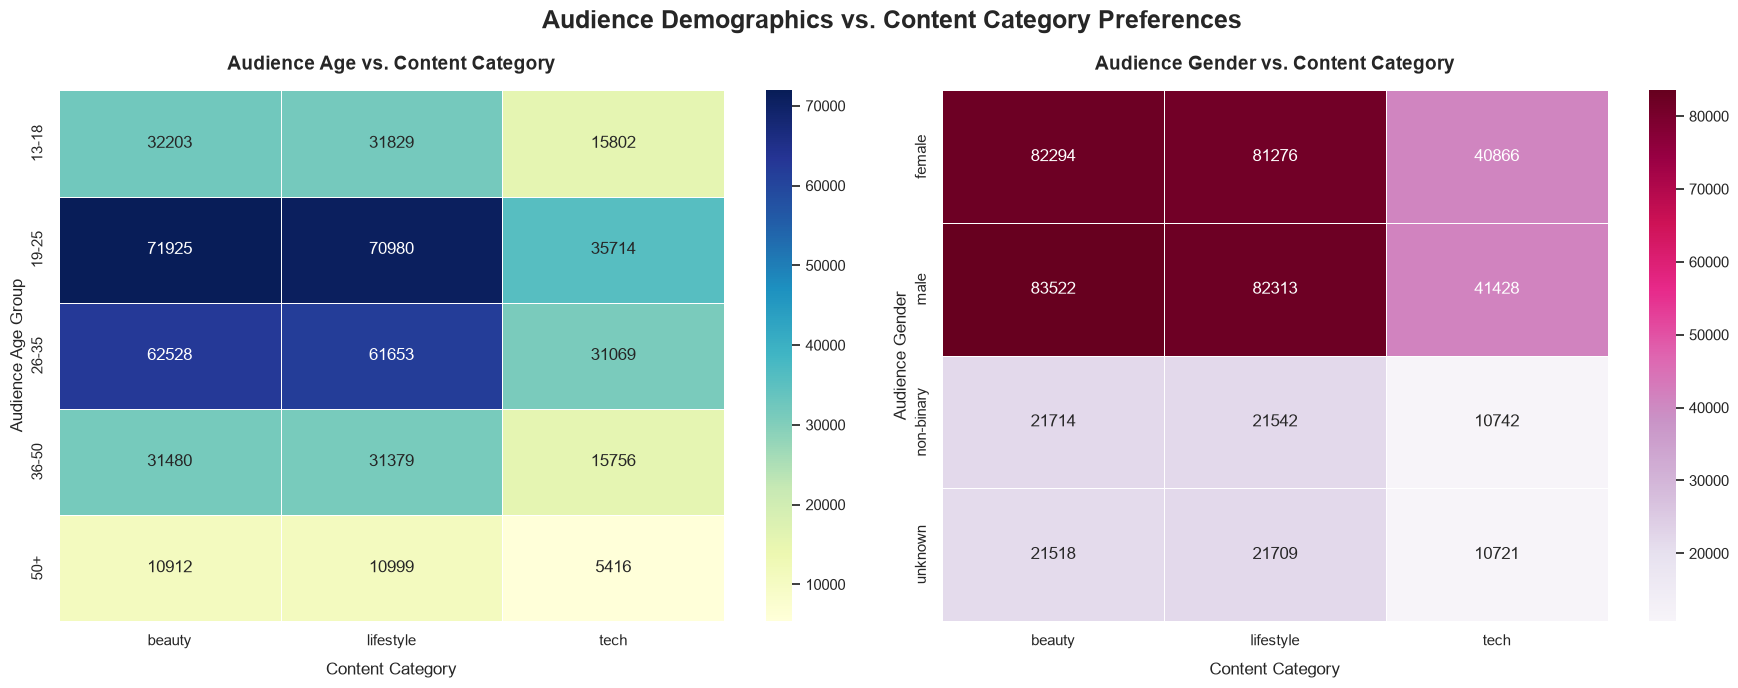


--- Most Watched Content Category by Age Group ---


,audience_age_distribution,content_category,view_count
0,13-18,beauty,32203
1,19-25,beauty,71925
2,26-35,beauty,62528
3,36-50,beauty,31480
4,50+,lifestyle,10999


In [10]:
# 1. Group data by Age and Content Category, then count occurrences
age_content = df_merged.groupby(['audience_age_distribution', 'content_category']).size().reset_index(name='view_count')
age_pivot = age_content.pivot(index='audience_age_distribution', columns='content_category', values='view_count')

# 2. Group data by Gender and Content Category, then count occurrences
gender_content = df_merged.groupby(['audience_gender_distribution', 'content_category']).size().reset_index(name='view_count')
gender_pivot = gender_content.pivot(index='audience_gender_distribution', columns='content_category', values='view_count')

# --- 3. Visualizing the Data (Heatmaps) ---

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Audience Demographics vs. Content Category Preferences', fontsize=18, fontweight='bold')

# Plot 1: Heatmap for Age vs Content Category
sns.heatmap(
    age_pivot,
    cmap='YlGnBu', # Yellow-Green-Blue color scale
    annot=True,    # Show numbers inside the boxes
    fmt='d',       # Format numbers as integers
    linewidths=.5,
    ax=axes[0]
)
axes[0].set_title('Audience Age vs. Content Category', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Content Category', fontsize=12, labelpad=10)
axes[0].set_ylabel('Audience Age Group', fontsize=12)

# Plot 2: Heatmap for Gender vs Content Category
sns.heatmap(
    gender_pivot,
    cmap='PuRd',   # Purple-Red color scale
    annot=True,
    fmt='d',
    linewidths=.5,
    ax=axes[1]
)
axes[1].set_title('Audience Gender vs. Content Category', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Content Category', fontsize=12, labelpad=10)
axes[1].set_ylabel('Audience Gender', fontsize=12)

plt.tight_layout()
plt.show()

# --- 4. Tabular Summary: Most Popular Category per Age Group ---
print("\n--- Most Watched Content Category by Age Group ---")
# Find the index of the max view_count for each age group, then extract those rows
top_content_by_age = age_content.loc[age_content.groupby('audience_age_distribution')['view_count'].idxmax()]
display(top_content_by_age.reset_index(drop=True))

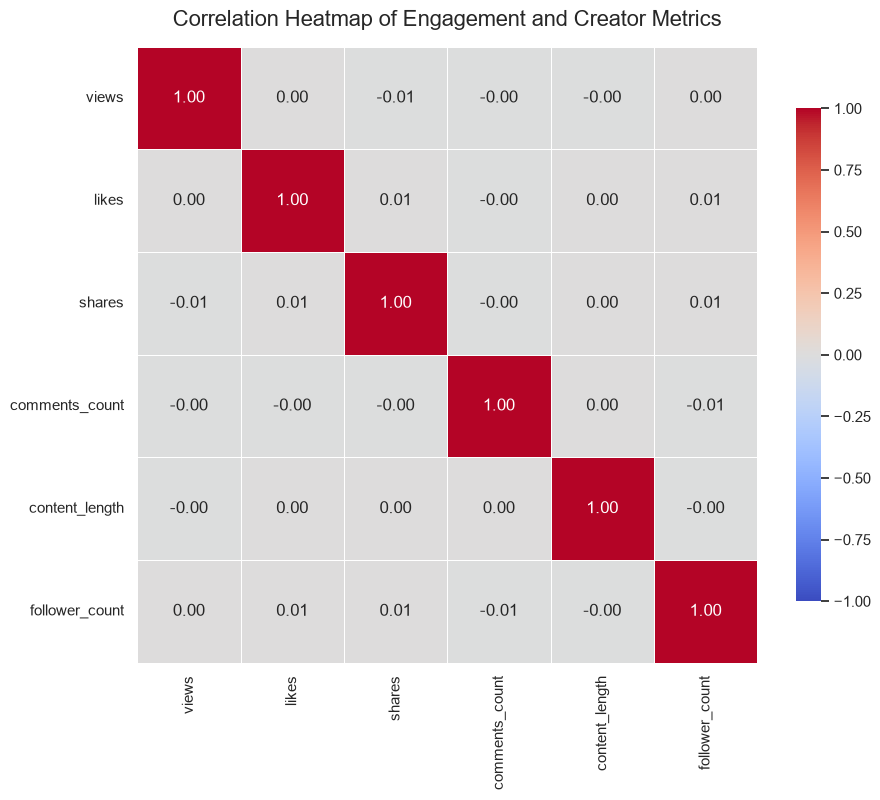

In [11]:
# Define the key numerical columns for the correlation analysis
numerical_features = ['views', 'likes', 'shares', 'comments_count', 'content_length', 'follower_count']

# Calculate the correlation matrix
corr_matrix = df_merged[numerical_features].corr()

# Set up the matplotlib figure size
plt.figure(figsize=(10, 8))

# Create the heatmap using seaborn
sns.heatmap(corr_matrix,
            annot=True,           # Display the correlation coefficients on the map
            cmap='coolwarm',      # Use a divergent color palette (blue for negative, red for positive)
            fmt=".2f",            # Format numbers to 2 decimal places
            linewidths=0.5,       # Add a small line between cells for better readability
            vmin=-1, vmax=1,      # Set the scale from -1 to +1
            cbar_kws={"shrink": .8})

# Add a descriptive title
plt.title('Correlation Heatmap of Engagement and Creator Metrics', fontsize=16, pad=15)

# Display the plot
plt.show()

## STATS

In [12]:
import scipy.stats as stats
from statsmodels.stats.weightstats import ztest
import pandas as pd

# ==========================================
# 1. TWO-SAMPLE T-TEST
# ==========================================
# Hypothesis: Is there a significant difference in average 'likes' between Video and Image content?
# H0: Mean likes for Video = Mean likes for Image
# HA: Mean likes for Video != Mean likes for Image

print("="*60)
print("1. TWO-SAMPLE T-TEST (Likes: Video vs Image)")
print("="*60)

likes_video = df_merged[df_merged['content_type'] == 'video']['likes'].dropna()
likes_image = df_merged[df_merged['content_type'] == 'image']['likes'].dropna()

t_stat, p_val_t = stats.ttest_ind(likes_video, likes_image, equal_var=False)
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_val_t:.4e}")

if p_val_t < 0.05:
    print("Conclusion: Reject the Null Hypothesis. There IS a statistically significant difference in likes between Video and Image content.")
else:
    print("Conclusion: Fail to reject Null Hypothesis. There is no significant difference in likes between Video and Image content.")


# ==========================================
# 2. TWO-SAMPLE Z-TEST
# ==========================================
# Hypothesis: Is there a significant difference in average 'views' between YouTube and TikTok?
# (We use a Z-test here because our sample size is massive, well over 30)
# H0: Mean views for YouTube = Mean views for TikTok
# HA: Mean views for YouTube != Mean views for TikTok

print("\n" + "="*60)
print("2. TWO-SAMPLE Z-TEST (Views: YouTube vs TikTok)")
print("="*60)

views_yt = df_merged[df_merged['platform'] == 'YouTube']['views'].dropna()
views_tt = df_merged[df_merged['platform'] == 'TikTok']['views'].dropna()

z_stat, p_val_z = ztest(views_yt, views_tt, value=0)
print(f"Z-Statistic: {z_stat:.4f}")
print(f"P-Value: {p_val_z:.4e}")

if p_val_z < 0.05:
    print("Conclusion: Reject the Null Hypothesis. There IS a statistically significant difference in views between YouTube and TikTok.")
else:
    print("Conclusion: Fail to reject Null Hypothesis. There is no significant difference in views between YouTube and TikTok.")


# ==========================================
# 3. CHI-SQUARE TEST OF INDEPENDENCE
# ==========================================
# Hypothesis: Are 'Audience Gender' and 'Content Category' dependent on each other?
# H0: Gender and Content Category are strictly independent (no relationship).
# HA: Gender and Content Category are dependent (certain genders prefer certain content).

print("\n" + "="*60)
print("3. CHI-SQUARE TEST OF INDEPENDENCE (Gender vs Content Category)")
print("="*60)

# Create a contingency table (cross-tabulation of the two categorical variables)
contingency_table = pd.crosstab(df_merged['audience_gender_distribution'], df_merged['content_category'])

chi2_stat, p_val_chi, dof, expected = stats.chi2_contingency(contingency_table)
print(f"Chi-Square Statistic: {chi2_stat:.4f}")
print(f"P-Value: {p_val_chi:.4e}")
print(f"Degrees of Freedom: {dof}")

if p_val_chi < 0.05:
    print("Conclusion: Reject the Null Hypothesis. Audience gender and content category are DEPENDENT (Specific demographics heavily favor specific content).")
else:
    print("Conclusion: Fail to reject Null Hypothesis. Audience gender and content category are independent.")
print("="*60)

1. TWO-SAMPLE T-TEST (Likes: Video vs Image)
T-Statistic: 0.9512
P-Value: 3.4149e-01
Conclusion: Fail to reject Null Hypothesis. There is no significant difference in likes between Video and Image content.

2. TWO-SAMPLE Z-TEST (Views: YouTube vs TikTok)
Z-Statistic: -5.3374
P-Value: 9.4308e-08
Conclusion: Reject the Null Hypothesis. There IS a statistically significant difference in views between YouTube and TikTok.

3. CHI-SQUARE TEST OF INDEPENDENCE (Gender vs Content Category)
Chi-Square Statistic: 5.5660
P-Value: 4.7352e-01
Degrees of Freedom: 6
Conclusion: Fail to reject Null Hypothesis. Audience gender and content category are independent.


In [13]:
# Import necessary Machine Learning libraries from scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np
import pandas as pd

# 1. Define Features (X) and Target (y)
# We are predicting 'likes' using other numerical variables
feature_cols = ['views', 'shares', 'comments_count', 'follower_count']
X = df_merged[feature_cols]
y = df_merged['likes']

# 2. Split the dataset into Training and Testing sets (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and Train the Multiple Linear Regression Model
mlr_model = LinearRegression()
mlr_model.fit(X_train, y_train)

# 4. Make Predictions on the Test set
y_pred = mlr_model.predict(X_test)

# 5. Evaluate the Model's Performance
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print("="*50)
print(" MULTIPLE LINEAR REGRESSION EVALUATION METRICS")
print("="*50)
print(f"R-squared (R2) Score          : {r2:.4f}")
print(f"Mean Absolute Error (MAE)     : {mae:.4f}")
print(f"Mean Squared Error (MSE)      : {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print("="*50)

# 6. Display the Equation Coefficients
print("\nFeature Coefficients:")
coefficients = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': mlr_model.coef_
})
# Sort to see which features have the highest positive/negative impact
print(coefficients.sort_values(by='Coefficient', ascending=False).to_string(index=False))
print(f"\nY-Intercept: {mlr_model.intercept_:.4f}")

 MULTIPLE LINEAR REGRESSION EVALUATION METRICS
R-squared (R2) Score          : 0.0001
Mean Absolute Error (MAE)     : 30.8649
Mean Squared Error (MSE)      : 1489.2990
Root Mean Squared Error (RMSE): 38.5914

Feature Coefficients:
       Feature   Coefficient
        shares  1.467960e-02
         views  5.512399e-04
follower_count  7.948497e-07
comments_count -6.429217e-03

Y-Intercept: 1501.1571


In [14]:
# Import Logistic Regression and Classification Metrics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd

# 1. Create a Binary Target Variable
# Find the median likes and create a 1/0 column for High/Low Engagement
median_likes = df_merged['likes'].median()
df_merged['is_high_engagement'] = (df_merged['likes'] > median_likes).astype(int)

# 2. Define Features (X) and Target (y)
# VERY IMPORTANT: We must exclude 'likes' from our features since it was used to create our target!
feature_cols = ['views', 'shares', 'comments_count', 'follower_count']
X = df_merged[feature_cols]
y = df_merged['is_high_engagement']

# 3. Split the dataset (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize and Train the Logistic Regression Model
# max_iter is increased to ensure the model converges properly
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)

# 5. Make Predictions on the Test set
y_pred = log_model.predict(X_test)

# 6. Evaluate the Model's Performance
accuracy = accuracy_score(y_test, y_pred)

print("="*50)
print(" LOGISTIC REGRESSION EVALUATION METRICS")
print("="*50)
print(f"Target Median Liked Threshold : {median_likes}")
print(f"Overall Accuracy              : {accuracy * 100:.2f}%\n")

print("--- Classification Report ---")
# This shows Precision, Recall, and F1-Score for both the 0 and 1 classes
print(classification_report(y_test, y_pred))

print("--- Confusion Matrix ---")
# This shows True Positives, True Negatives, False Positives, and False Negatives
print(confusion_matrix(y_test, y_pred))
print("="*50)

 LOGISTIC REGRESSION EVALUATION METRICS
Target Median Liked Threshold : 1510.0
Overall Accuracy              : 50.44%

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.50      0.87      0.64     52313
           1       0.50      0.13      0.21     51616

    accuracy                           0.50    103929
   macro avg       0.50      0.50      0.43    103929
weighted avg       0.50      0.50      0.43    103929

--- Confusion Matrix ---
[[45491  6822]
 [44686  6930]]


In [15]:
# Import clustering and scaling libraries
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# 1. Select the numerical features for clustering
cluster_features = ['views', 'likes', 'shares', 'comments_count', 'follower_count']
X_cluster = df_merged[cluster_features]

# 2. Scale the features (Crucial for distance-based algorithms like K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# 3. Initialize and fit the K-Means Model
# We'll start with 4 clusters as a baseline exploration
num_clusters = 4
kmeans = KMeans(n_clusters=num_clusters, init='k-means++', random_state=42, n_init=10)
df_merged['cluster_label'] = kmeans.fit_predict(X_scaled)

# 4. Profile the Clusters
# Calculate the average values of our metrics for each group to see what they represent
cluster_profile = df_merged.groupby('cluster_label')[cluster_features].mean()

# Add the total number of posts in each cluster
cluster_profile['post_count'] = df_merged['cluster_label'].value_counts()

print("="*65)
print("              K-MEANS CLUSTER PROFILES (MEANS)")
print("="*65)
print(cluster_profile.round(2).to_string())
print("="*65)

              K-MEANS CLUSTER PROFILES (MEANS)
                  views    likes  shares  comments_count  follower_count  post_count
cluster_label                                                                       
0              10054.85  1533.10  308.02          205.67       273368.44      125616
1              10128.43  1523.50  307.14          191.36       744157.59      135771
2              10068.88  1494.42  291.38          209.67       711528.13      125580
3              10144.24  1490.04  293.29          194.39       257763.28      132678


In [16]:
# Import K-NN, Scaling, and Evaluation tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd

# 1. Performance Check: Take a random sample of 20,000 rows to prevent Colab from freezing
df_sample = df_merged.sample(n=20000, random_state=42).copy()

# 2. Ensure the binary target exists in our sample
if 'is_high_engagement' not in df_sample.columns:
    median_likes = df_merged['likes'].median()
    df_sample['is_high_engagement'] = (df_sample['likes'] > median_likes).astype(int)

# 3. Define Features (X) and Target (y)
feature_cols = ['views', 'shares', 'comments_count', 'follower_count']
X = df_sample[feature_cols]
y = df_sample['is_high_engagement']

# 4. Split the dataset into Training and Testing sets (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Scale Features (Mandatory for distance-based algorithms like K-NN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Initialize and Train K-NN Classifier (Using k=5 neighbors as a baseline)
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

# 7. Make Predictions on the scaled test set
y_pred = knn_model.predict(X_test_scaled)

# 8. Evaluate the Model's Performance
accuracy = accuracy_score(y_test, y_pred)

print("="*50)
print("       K-NEAREST NEIGHBORS (K-NN) EVALUATION")
print("="*50)
print(f"Overall Accuracy: {accuracy * 100:.2f}%\n")

print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))
print("="*50)

       K-NEAREST NEIGHBORS (K-NN) EVALUATION
Overall Accuracy: 55.77%

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.55      0.58      0.56      1968
           1       0.57      0.54      0.55      2032

    accuracy                           0.56      4000
   macro avg       0.56      0.56      0.56      4000
weighted avg       0.56      0.56      0.56      4000

--- Confusion Matrix ---
[[1137  831]
 [ 938 1094]]


--- 1. CLASSIFICATION MODELS (Comparing Logistic Regression vs K-NN) ---
Logistic Regression Accuracy: 0.4915
K-Nearest Neighbors Accuracy: 0.5460


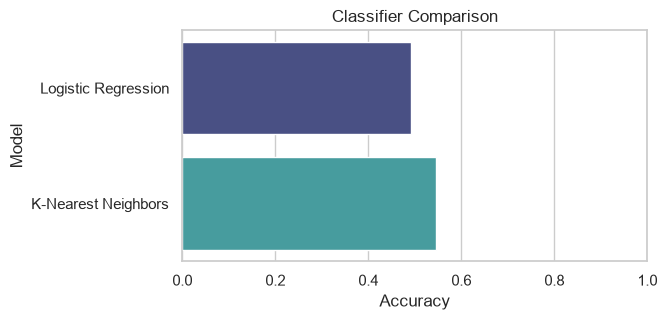


--- 2. REGRESSION MODEL (Multiple Linear Regression) ---
Multiple Linear Regression -> R-squared: -0.0016 | MSE: 0.25

--- 3. CLUSTERING MODEL (K-Means) ---
K-Means (3 clusters) -> Silhouette Score: 0.5948
Cluster Centers (Inertia): 145906903681289.62


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import the 4 specific models
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans

# Import respective metrics
from sklearn.metrics import accuracy_score, r2_score, mean_squared_error, silhouette_score

print("--- 1. CLASSIFICATION MODELS (Comparing Logistic Regression vs K-NN) ---")
# These predict categories/labels. We can compare them using Accuracy.
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier()
}

class_results = []
for name, model in classifiers.items():
    model.fit(X_train, y_train) # Assuming y_train is categorical
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    class_results.append({"Model": name, "Accuracy": acc})
    print(f"{name} Accuracy: {acc:.4f}")

# Visualize the two classifiers
df_class = pd.DataFrame(class_results)
plt.figure(figsize=(6, 3))
sns.barplot(data=df_class, x='Accuracy', y='Model', palette='mako')
plt.title('Classifier Comparison')
plt.xlim(0, 1.0)
plt.show()

print("\n--- 2. REGRESSION MODEL (Multiple Linear Regression) ---")
# This predicts continuous numbers. Evaluated with R-squared and MSE.
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train) # Assuming y_train is continuous here for regression testing
y_pred_reg = lin_reg.predict(X_test)

r2 = r2_score(y_test, y_pred_reg)
mse = mean_squared_error(y_test, y_pred_reg)
print(f"Multiple Linear Regression -> R-squared: {r2:.4f} | MSE: {mse:.2f}")


print("\n--- 3. CLUSTERING MODEL (K-Means) ---")
# This is unsupervised (no y_test or y_train used). It just groups the X data.
# We will test it with an arbitrary 3 clusters for this example.
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
cluster_labels = kmeans.fit_predict(X_train)

# Evaluated using Silhouette Score (1 is best, -1 is worst, near 0 means overlapping clusters)
sil_score = silhouette_score(X_train, cluster_labels)
print(f"K-Means (3 clusters) -> Silhouette Score: {sil_score:.4f}")
print(f"Cluster Centers (Inertia): {kmeans.inertia_:.2f}")